# Customer Churn Prediction - Machine Learning Project

## Problem Statement

The goal of this project is to predict whether a customer will churn or not based on customer information such as contract type, tenure, monthly charges, internet service, payment method, and other features.

This is a binary classification problem.

Target column:

- Churn = Yes means the customer left
- Churn = No means the customer stayed


## Import Required Libraries


In [1]:
# Basic libraries for data handling
import numpy as np
import pandas as pd

# Libraries for visualization
import matplotlib.pylab as plt
import seaborn as sns

# Display all columns properly
pd.set_option("display.max_columns", None)

# Ignore unnecessary warnings
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    r"C:\Users\infor\OneDrive\Desktop\Machine Learning\Exercise Project 1\DataSet\Telco-Customer-Churn.csv"
)

In [3]:
df.shape

(7043, 21)

In [4]:
# Show all column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Check data types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [9]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print(f"Numerical columns: {numerical_columns}")
print(f"\nCategorical columns: {numerical_columns}")

Numerical columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

Categorical columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


## Check Target Column


In [10]:
# Check target column values
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage view:


In [11]:
# Check percentage of each class
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

This shows that it is highly imbalanced


## Visualize Target Distribution


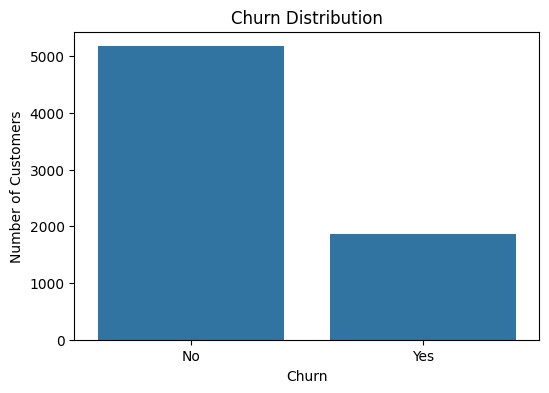

In [12]:
# Visualize Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [13]:
# Statistical summary for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
# Summary for categorical columns
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [15]:
# Calculate Churn rate
churn_rate = df["Churn"].value_counts(normalize=True)["Yes"] * 100

print(f"Customer churn rate: {churn_rate:.2f}%")

Customer churn rate: 26.54%


Copy the Dataset


In [16]:
df_clean = df.copy()

df_clean.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [17]:
print("Shape before cleaning:", df_clean.shape)

Shape before cleaning: (7043, 21)


## Drop Unnecessary Colum `customerID`


In [18]:
df_clean.drop("customerID", axis=1, inplace=True)

In [19]:
df_clean["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [20]:
# Check values where TotalCharges contains blank spaces
df_clean[df_clean["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## Convert `TotalCharges` to Numeric


In [21]:
# errors='coerce' converts invalid values like blank space into NaN
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
# Show rows where TotalCharges is missing
df_clean[df_clean["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


# Handle Missing `TotalCharges`


In [24]:
# Drop rows where TotalCharges is missing
df_clean.dropna(subset=["TotalCharges"], inplace=True)

# Check missing values again
df_clean.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
# Reset index after dropping rows
df_clean.reset_index(drop=True, inplace=True)

# Check first 5 rows
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
# Check and remove duplicate rows
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df_clean.drop_duplicates(inplace=True)
    df_clean.reset_index(drop=True, inplace=True)

print("Shape after duplicate handling:", df_clean.shape)


Number of duplicate rows: 22
Shape after duplicate handling: (7010, 20)


In [28]:
# Convert target column Churn
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

print("\nTarget column after conversion:")
print(df_clean["Churn"].value_counts())

print("\nTarget percentage:")
print(df_clean["Churn"].value_counts(normalize=True) * 100)


Target column after conversion:
Churn
0    5153
1    1857
Name: count, dtype: int64

Target percentage:
Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64


In [ ]:
# Check final data types

print("\nFinal data types:")
print(df_clean.dtypes)


Final data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [34]:
# Final missing value check

print("\nFinal missing values:")
print(df_clean.isnull().sum())


Final missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [33]:
# Separate features and target

X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (7010, 19)
y shape: (7010,)


In [35]:
# Identify numerical and categorical columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [36]:
# Check unique values in categorical columns

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(df_clean[col].unique())
    print("Number of unique values:", df_clean[col].nunique())


Column: gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Number of unique values: 2

Column: Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Number of unique values: 2

Column: Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2

Column: PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2

Column: MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Number of unique values: 3

Column: InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Number of unique values: 3

Column: OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Number of unique values: 3

Column: OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Number of unique values: 3

Column: DeviceProtection
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length:

In [40]:
# Save cleaned dataset

df_clean.to_csv("DataSet/Telco-Customer-Churn-Cleaned.csv", index=False)

print("\nCleaned dataset saved successfully.")
print("Final cleaned dataset shape:", df_clean.shape)


Cleaned dataset saved successfully.
Final cleaned dataset shape: (7010, 20)
